<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exercise 01 of the course 01ZLMA.

## Contents

*   Recap of multivariable linear regression (FJFI course 01RAD)
*   Discussion about organizational/run of the course
*   Introduction into Google colab notebooks (R version https://colab.to/r or Python versions)
* **Exponential type distributions**


In [54]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [55]:
# Load the R magic extension
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Regression analysis


Dataset description:
https://jse.amstat.org/datasets/fishcatch.txt



### Fish Catch Dataset

159 fishes of 7 species are caught and measured. Altogether there are
8 variables.  All the fishes are caught from the same lake
(Laengelmavesi) near Tampere in Finland.

SOURCES:
Brofeldt, Pekka: Bidrag till kaennedom on fiskbestondet i vaera
        sjoear. Laengelmaevesi. T.H.Jaervi: Finlands Fiskeriet  Band 4,
        Meddelanden utgivna av fiskerifoereningen i Finland.
        Helsingfors 1917

VARIABLE DESCRIPTIONS:

1.  Obs       Observation number ranges from 1 to 159
2.  Species   (Numeric)
        Code Finnish  Swedish    English        Latin      
         1   Lahna    Braxen     Bream          Abramis brama
         2   Siika    Iiden      Whitewish      Leusiscus idus
         3   Saerki   Moerten    Roach          Leuciscus rutilus
         4   Parkki   Bjoerknan  Blicca         Abramis bjrkna
         5   Norssi   Norssen    Smelt          Osmerus eperlanus
         6   Hauki    Jaedda     Pike           Esox lucius
         7   Ahven    Abborre    Perch          Perca fluviatilis

3.  Weight      Weight of the fish (in grams)
4.  Length1     Length from the nose to the beginning of the tail (in cm)
5.  Length2     Length from the nose to the notch of the tail (in cm)
6.  Length3     Length from the nose to the end of the tail (in cm)
7.  Height%     Maximal height as % of Length3
8.  Width%      Maximal width as % of Length3
9.  Sex         1 = male 0 = female



In [56]:
# Read the dataset without column names
import io
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://jse.amstat.org/datasets/fishcatch.dat.txt"
col_names = ['Obs', 'Species', 'Weight', 'Len1', 'Len2', 'Len3', 'Height', 'Width', 'Sex']
response = requests.get(url, verify=False)
fishcatch = pd.read_csv(io.StringIO(response.text), sep=r'\s+', header=None, names=col_names)
fishcatch

,Obs,Species,Weight,Len1,Len2,Len3,Height,Width,Sex
0,1,1,242.0,23.2,25.4,30.0,38.4,13.4,NaN
1,2,1,290.0,24.0,26.3,31.2,40.0,13.8,NaN
2,3,1,340.0,23.9,26.5,31.1,39.8,15.1,NaN
3,4,1,363.0,26.3,29.0,33.5,38.0,13.3,NaN
4,5,1,430.0,26.5,29.0,34.0,36.6,15.1,NaN
...,...,...,...,...,...,...,...,...,...
154,155,7,1100.0,39.0,42.0,44.6,28.7,15.4,0.0
155,156,7,1000.0,39.8,43.0,45.2,26.4,16.1,0.0
156,157,7,1100.0,40.1,43.0,45.5,27.5,16.3,0.0
157,158,7,1000.0,40.2,43.5,46.0,27.4,17.7,1.0


In [57]:
# Remove rows with missing Weight
fish = fishcatch.dropna(subset=['Weight']).copy()

# Replace missing values in 'Sex' with "unknown"
fish['Sex'] = fish['Sex'].fillna("unknown")

# Recode Sex: change 1 -> "male", 0 -> "female"
fish['Sex'] = fish['Sex'].replace({1: "male", 0: "female", '1': "male", '0': "female"})

# Convert 'Sex' and 'Species' to categorical types
fish['Sex'] = fish['Sex'].astype('category')
fish['Species'] = fish['Species'].astype('category')

# Drop the Obs column
fish = fish.drop(columns=['Obs'])

# Display summary statistics (all columns)
summary = fish.describe(include='all').T
print(summary)


         count unique      top  freq       mean         std   min     25%  \
Species  158.0    7.0      7.0  56.0        NaN         NaN   NaN     NaN   
Weight   158.0    NaN      NaN   NaN  398.69557  359.086204   0.0   120.0   
Len1     158.0    NaN      NaN   NaN  26.226582   10.024844   7.5  19.025   
Len2     158.0    NaN      NaN   NaN  28.393038   10.746572   8.4    21.0   
Len3     158.0    NaN      NaN   NaN  31.188608    11.63701   8.8  23.125   
Height   158.0    NaN      NaN   NaN  28.256329    8.296377  14.5  24.225   
Width    158.0    NaN      NaN   NaN   14.11962    2.281229   8.7    13.4   
Sex        158      3  unknown    87        NaN         NaN   NaN     NaN   

           50%     75%     max  
Species    NaN     NaN     NaN  
Weight   272.5   650.0  1650.0  
Len1      25.1    32.7    59.0  
Len2     27.15   35.75    63.4  
Len3     29.35  39.675    68.0  
Height    27.0    37.7    44.5  
Width     14.6    15.3    20.9  
Sex        NaN     NaN     NaN  


In [58]:
fish

,Species,Weight,Len1,Len2,Len3,Height,Width,Sex
0,1,242.0,23.2,25.4,30.0,38.4,13.4,unknown
1,1,290.0,24.0,26.3,31.2,40.0,13.8,unknown
2,1,340.0,23.9,26.5,31.1,39.8,15.1,unknown
3,1,363.0,26.3,29.0,33.5,38.0,13.3,unknown
4,1,430.0,26.5,29.0,34.0,36.6,15.1,unknown
...,...,...,...,...,...,...,...,...
154,7,1100.0,39.0,42.0,44.6,28.7,15.4,female
155,7,1000.0,39.8,43.0,45.2,26.4,16.1,female
156,7,1100.0,40.1,43.0,45.5,27.5,16.3,female
157,7,1000.0,40.2,43.5,46.0,27.4,17.7,male


In [59]:
print(fish.describe(include='all').T)

         count unique      top  freq       mean         std   min     25%  \
Species  158.0    7.0      7.0  56.0        NaN         NaN   NaN     NaN   
Weight   158.0    NaN      NaN   NaN  398.69557  359.086204   0.0   120.0   
Len1     158.0    NaN      NaN   NaN  26.226582   10.024844   7.5  19.025   
Len2     158.0    NaN      NaN   NaN  28.393038   10.746572   8.4    21.0   
Len3     158.0    NaN      NaN   NaN  31.188608    11.63701   8.8  23.125   
Height   158.0    NaN      NaN   NaN  28.256329    8.296377  14.5  24.225   
Width    158.0    NaN      NaN   NaN   14.11962    2.281229   8.7    13.4   
Sex        158      3  unknown    87        NaN         NaN   NaN     NaN   

           50%     75%     max  
Species    NaN     NaN     NaN  
Weight   272.5   650.0  1650.0  
Len1      25.1    32.7    59.0  
Len2     27.15   35.75    63.4  
Len3     29.35  39.675    68.0  
Height    27.0    37.7    44.5  
Width     14.6    15.3    20.9  
Sex        NaN     NaN     NaN  


C:\Users\francji1\AppData\Local\Temp\ipykernel_10856\1427853132.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('Species')


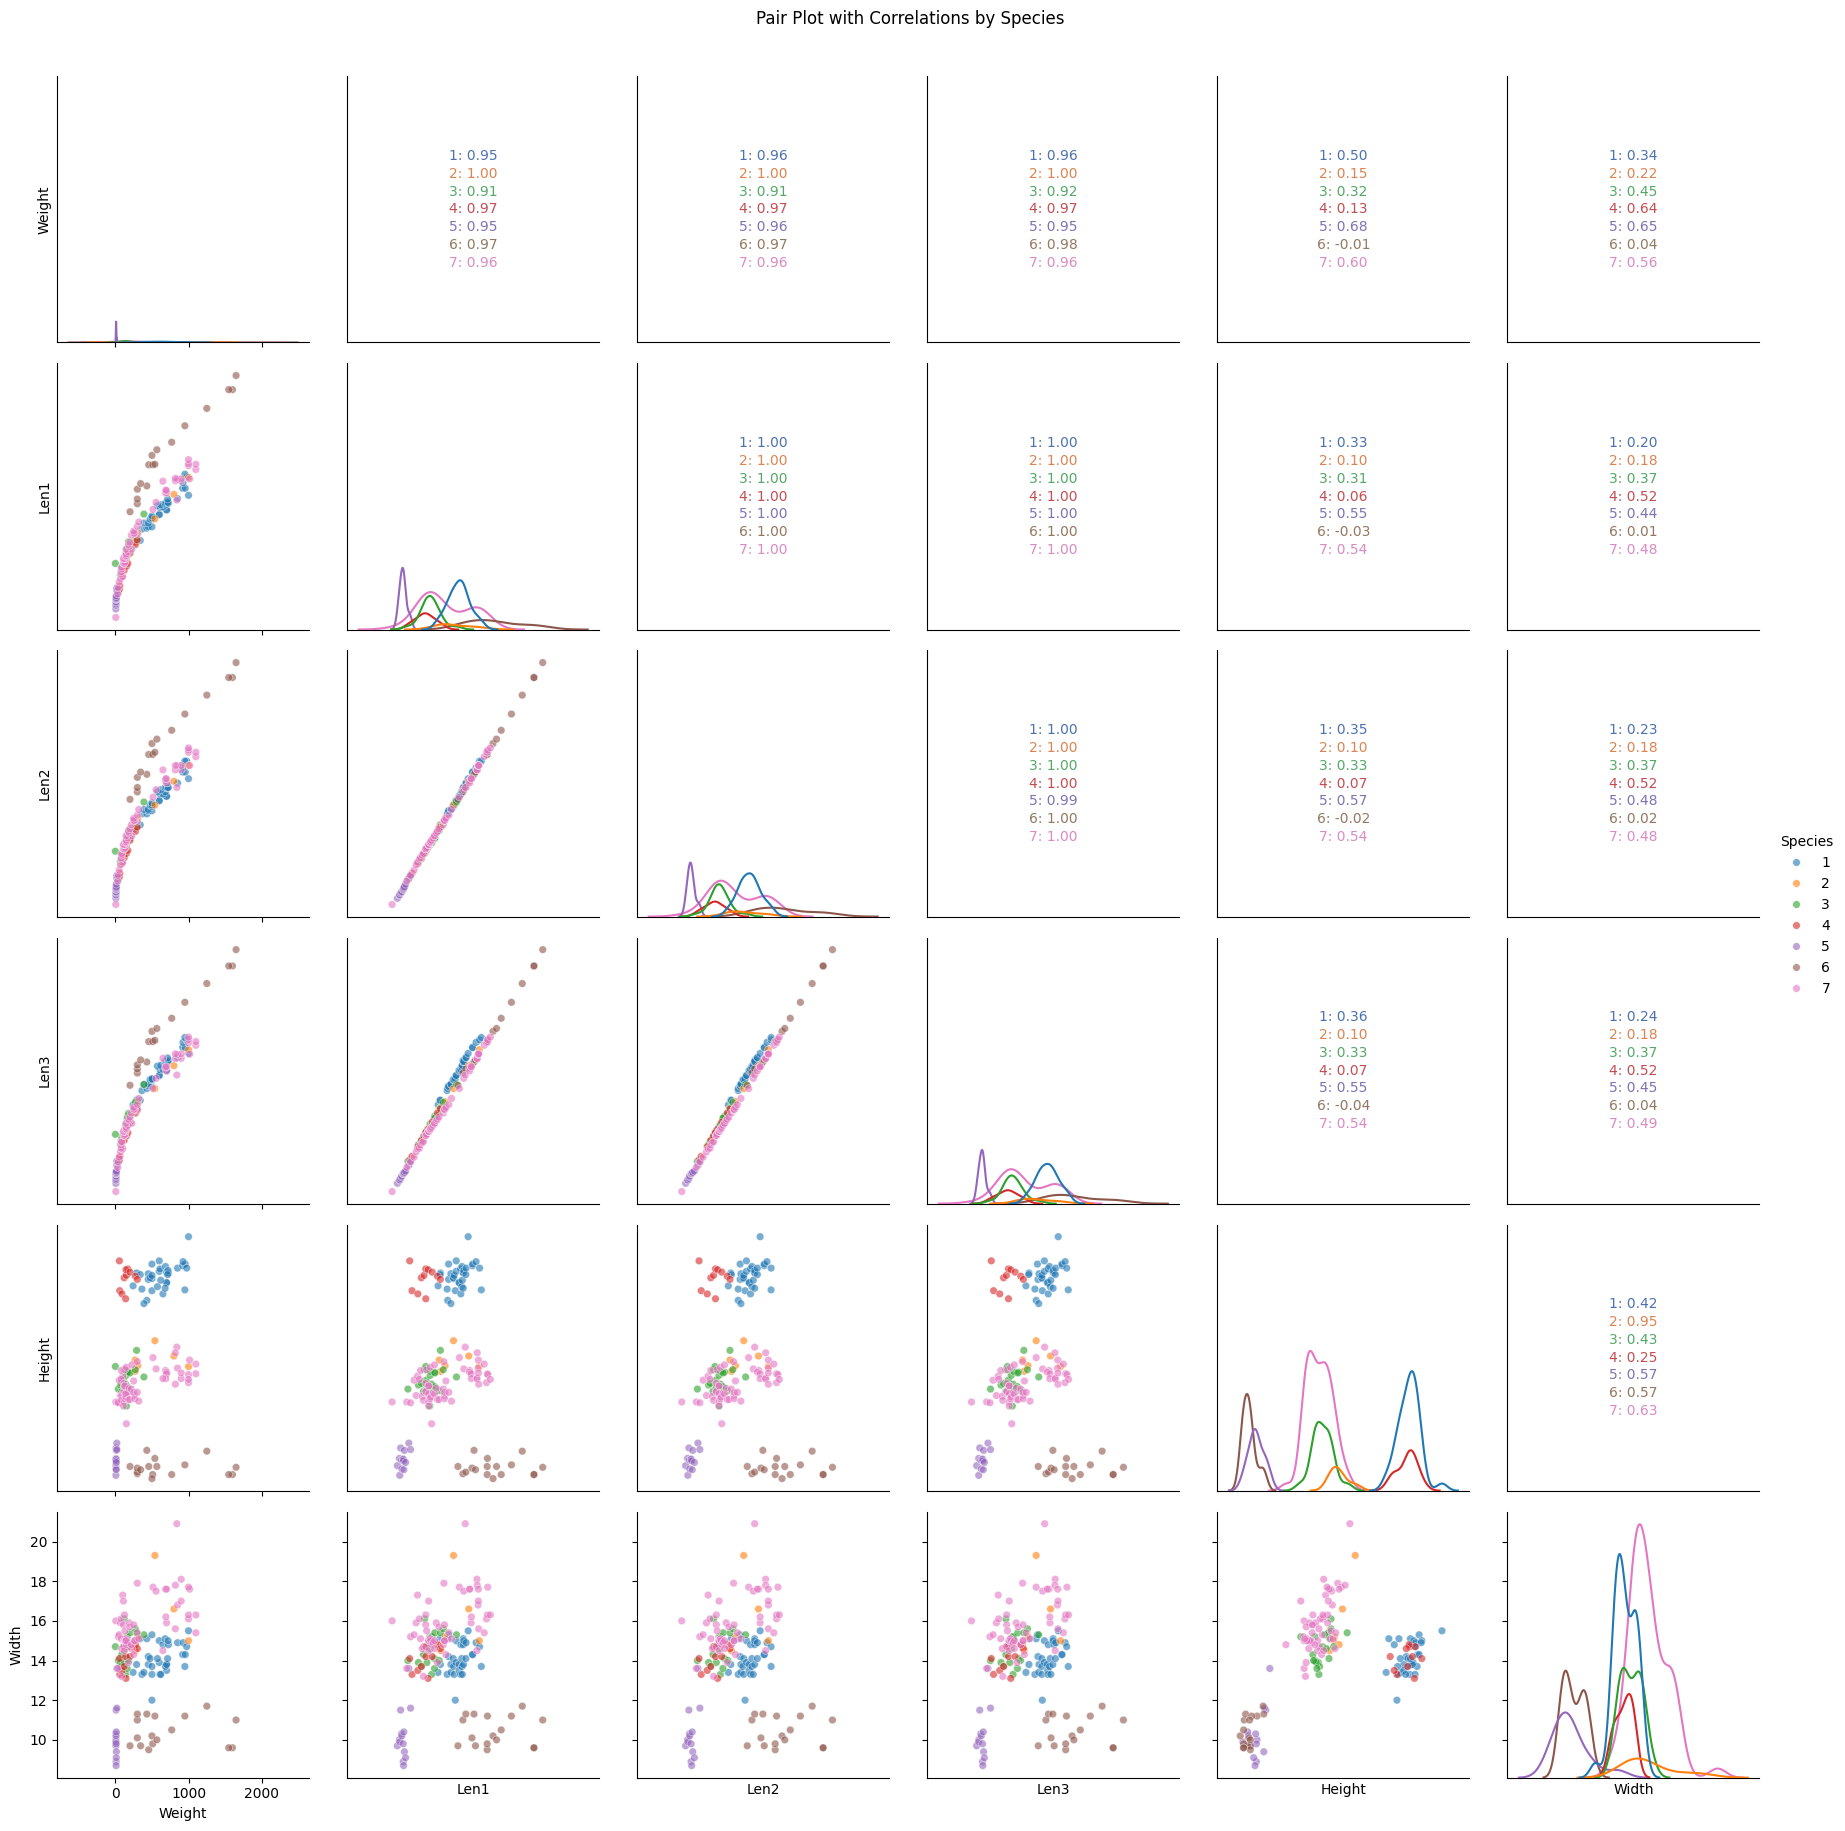

In [60]:
# Define the numeric variables for the pair plot.
num_vars = ['Weight', 'Len1', 'Len2', 'Len3', 'Height', 'Width']

# Create a palette mapping for species using the same palette as PairGrid.
species_categories = fish['Species'].cat.categories
palette = dict(zip(species_categories, sns.color_palette("deep", n_colors=len(species_categories))))

def corrcoef_per_species(x, y, **kwargs):
    ax = plt.gca()
    # Retrieve the corresponding subset of the original dataframe.
    subset = fish.loc[x.index]
    groups = subset.groupby('Species')
    species_list = list(groups.groups.keys())
    N = len(species_list)
    # Define vertical positions for each species annotation.
    offsets = np.linspace(0.7, 0.3, N) if N > 1 else [0.5]
    for sp, offset in zip(species_list, offsets):
        group_mask = subset['Species'] == sp
        x_group = x[group_mask]
        y_group = y[group_mask]
        if len(x_group) > 1:
            r = np.corrcoef(x_group, y_group)[0, 1]
            ax.text(0.5, offset, f"{sp}: {r:.2f}",
                    transform=ax.transAxes,
                    ha='center', va='center',
                    fontsize=10, color=palette[sp])
    ax.set_xticks([])
    ax.set_yticks([])

# Create a PairGrid with an enlarged figure.
g = sns.PairGrid(fish, vars=num_vars, hue='Species', height=3)
g.map_lower(sns.scatterplot, alpha=0.6, s=30)
g.map_diag(sns.kdeplot)
g.map_upper(corrcoef_per_species)
g.add_legend(title="Species")
plt.suptitle("Pair Plot with Correlations by Species", y=1.02)
plt.show()


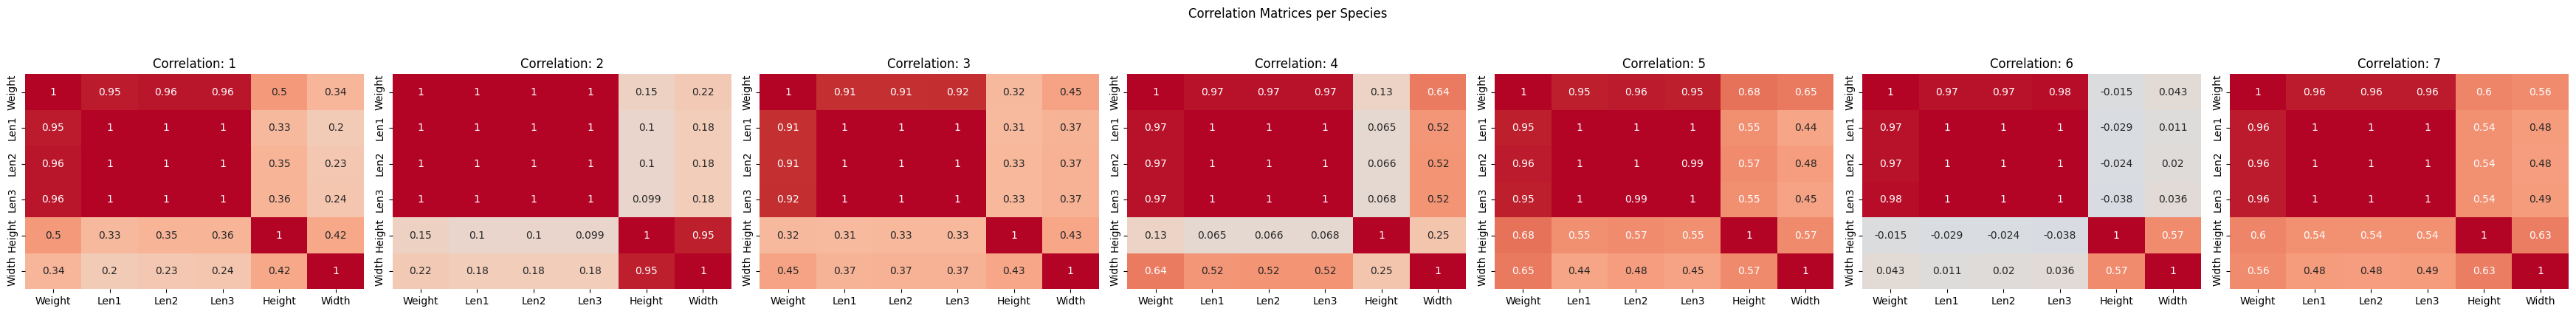

In [61]:
species_list = fish['Species'].cat.categories
num_vars = ['Weight', 'Len1', 'Len2', 'Len3', 'Height', 'Width']

n = len(species_list)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, sp in zip(axes, species_list):
    subset = fish[fish['Species'] == sp]
    corr = subset[num_vars].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=False)
    ax.set_title(f"Correlation: {sp}")

plt.suptitle("Correlation Matrices per Species", y=1.05)
plt.tight_layout()
plt.show()


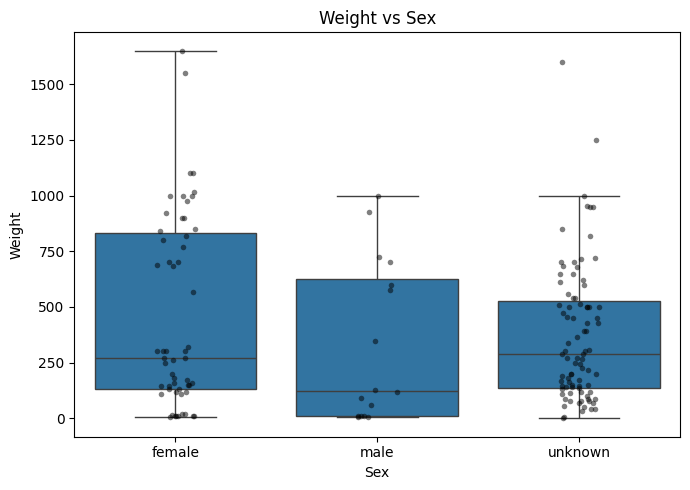

In [62]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Sex', y='Weight', data=fish, showfliers=False, linewidth=1)
sns.stripplot(x='Sex', y='Weight', data=fish, jitter=0.1, alpha=0.5, size=4, color='black')
plt.xlabel("Sex")
plt.ylabel("Weight")
plt.title("Weight vs Sex")
plt.tight_layout()
plt.show()


C:\Users\francji1\AppData\Local\Temp\ipykernel_10856\926874642.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='Species', y='Weight', hue='Sex', data=fish, dodge=True, jitter=0.1, alpha=0.5, size=4, color='black', legend=False)


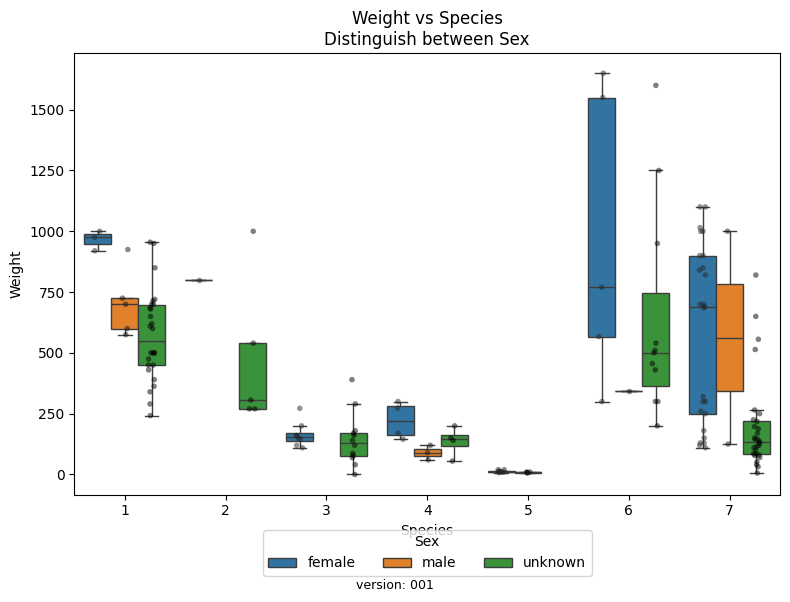

In [63]:
plt.figure(figsize=(8,6))
# Boxplot: grouping by Species and split by Sex
sns.boxplot(x='Species', y='Weight', hue='Sex', data=fish, showfliers=False, linewidth=1)
# Jittered points overlaid
sns.stripplot(x='Species', y='Weight', hue='Sex', data=fish, dodge=True, jitter=0.1, alpha=0.5, size=4, color='black', legend=False)
plt.title("Weight vs Species\nDistinguish between Sex")
plt.xlabel("Species")
plt.ylabel("Weight")
plt.figtext(0.5, 0.01, "version: 001", ha="center", fontsize=9)
plt.legend(title="Sex", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()


**To** load required libraries (with R runtime type):


In [64]:
%%R
#cat(system('sudo apt-get install -y gmp', intern=TRUE), sep = "\n")
#cat(system('sudo apt-get install -y partitions', intern=TRUE), sep = "\n")

list_of_packages <- c("tidyverse","dplyr","MASS","knitr", "GGally", "reactable","gridExtra","IRdisplay") #
missing_packages <- list_of_packages[!(list_of_packages %in% installed.packages()[,"Package"])]
missing_packages
if(length(missing_packages)) install.packages(missing_packages)
lapply(list_of_packages, library, character.only = TRUE)

#For sure: set dplyr functions
select    <- dplyr::select;
rename    <- dplyr::rename;
mutate    <- dplyr::mutate;
summarize <- dplyr::summarize;
arrange   <- dplyr::arrange;
slice     <- dplyr::slice;
filter    <- dplyr::filter;
recode    <- dplyr::recode

In [65]:
%%R
#@title Read dataset (without colnames)
fishcatch <- read.table("http://jse.amstat.org/datasets/fishcatch.dat.txt") %>%
  rename(Obs =V1,
         Species = V2,
         Weight = V3,
         Len1 = V4,
         Len2 = V5,
         Len3 = V6,
         Height = V7,
         Width = V8,
         Sex = V9
         )

head(fishcatch)
fishcatch %>%
   summary() %>%
   kable(format = "pipe")



|   |     Obs      |   Species    |    Weight     |     Len1     |     Len2     |     Len3     |    Height    |    Width     |     Sex       |
|:--|:-------------|:-------------|:--------------|:-------------|:-------------|:-------------|:-------------|:-------------|:--------------|
|   |Min.   :  1.0 |Min.   :1.000 |Min.   :   0.0 |Min.   : 7.50 |Min.   : 8.40 |Min.   : 8.80 |Min.   :14.50 |Min.   : 8.70 |Min.   :0.0000 |
|   |1st Qu.: 40.5 |1st Qu.:2.000 |1st Qu.: 120.0 |1st Qu.:19.05 |1st Qu.:21.00 |1st Qu.:23.15 |1st Qu.:24.25 |1st Qu.:13.40 |1st Qu.:0.0000 |
|   |Median : 80.0 |Median :5.000 |Median : 272.5 |Median :25.20 |Median :27.30 |Median :29.40 |Median :27.10 |Median :14.60 |Median :0.0000 |
|   |Mean   : 80.0 |Mean   :4.497 |Mean   : 398.7 |Mean   :26.25 |Mean   :28.42 |Mean   :31.23 |Mean   :28.31 |Mean   :14.12 |Mean   :0.2361 |
|   |3rd Qu.:119.5 |3rd Qu.:7.000 |3rd Qu.: 650.0 |3rd Qu.:32.70 |3rd Qu.:35.50 |3rd Qu.:39.65 |3rd Qu.:37.60 |3rd Qu.:15.30 |3rd Qu.:0.0000

Your working directory is in the cloud. You can mount your Google drive, or your local hard drive
(https://stackoverflow.com/questions/56679549/how-to-mount-google-drive-to-r-notebook-in-colab)
 (https://github.com/katewall/medium_tutorials/blob/main/210630_Medium_ColabwithR.ipynb).

In [66]:
%%R
R.version.string
getwd()

[1] "m:/01ZLMA/01ZLMA/code"


|   |     Obs      |   Species    |    Weight     |     Len1     |     Len2     |     Len3     |    Height    |    Width     |     Sex       |
|:--|:-------------|:-------------|:--------------|:-------------|:-------------|:-------------|:-------------|:-------------|:--------------|
|   |Min.   :  1.0 |Min.   :1.000 |Min.   :   0.0 |Min.   : 7.50 |Min.   : 8.40 |Min.   : 8.80 |Min.   :14.50 |Min.   : 8.70 |Min.   :0.0000 |
|   |1st Qu.: 40.5 |1st Qu.:2.000 |1st Qu.: 120.0 |1st Qu.:19.05 |1st Qu.:21.00 |1st Qu.:23.15 |1st Qu.:24.25 |1st Qu.:13.40 |1st Qu.:0.0000 |
|   |Median : 80.0 |Median :5.000 |Median : 272.5 |Median :25.20 |Median :27.30 |Median :29.40 |Median :27.10 |Median :14.60 |Median :0.0000 |
|   |Mean   : 80.0 |Mean   :4.497 |Mean   : 398.7 |Mean   :26.25 |Mean   :28.42 |Mean   :31.23 |Mean   :28.31 |Mean   :14.12 |Mean   :0.2361 |
|   |3rd Qu.:119.5 |3rd Qu.:7.000 |3rd Qu.: 650.0 |3rd Qu.:32.70 |3rd Qu.:35.50 |3rd Qu.:39.65 |3rd Qu.:37.60 |3rd Qu.:15.30 |3rd Qu.:0.0000 |
|   |Max.   :159.0 |Max.   :7.000 |Max.   :1650.0 |Max.   :59.00 |Max.   :63.40 |Max.   :68.00 |Max.   :44.50 |Max.   :20.90 |Max.   :1.0000 |
|   |NA            |NA            |NA's   :1      |NA            |NA            |NA            |NA            |NA            |NA's   :87     |

In [67]:
#reactable(fishcatch)

In [68]:
%%R
mutate_cond <- function(.data, condition, ..., envir = parent.frame()) {
  condition <- eval(substitute(condition), .data, envir)
  .data[condition, ] <- .data[condition, ] %>% mutate(...)
  .data
}

In [69]:
%%R
fish <- fishcatch %>%
  drop_na(Weight) %>%
  mutate_cond(is.na(Sex), Sex = "unknown") %>%
  mutate(Sex = as.factor(Sex)) %>%
  mutate(Sex = recode(Sex,"1" = "male", "0" = "female")) %>%
  mutate(Species = factor(Species)) %>%
  select(-Obs)
fish %>% summary() %>% kable()




|   |Species |    Weight     |     Len1     |     Len2     |     Len3     |    Height    |    Width     |     Sex   |
|:--|:-------|:--------------|:-------------|:-------------|:-------------|:-------------|:-------------|:----------|
|   |1:34    |Min.   :   0.0 |Min.   : 7.50 |Min.   : 8.40 |Min.   : 8.80 |Min.   :14.50 |Min.   : 8.70 |female :55 |
|   |2: 6    |1st Qu.: 120.0 |1st Qu.:19.02 |1st Qu.:21.00 |1st Qu.:23.12 |1st Qu.:24.23 |1st Qu.:13.40 |male   :16 |
|   |3:20    |Median : 272.5 |Median :25.10 |Median :27.15 |Median :29.35 |Median :27.00 |Median :14.60 |unknown:87 |
|   |4:11    |Mean   : 398.7 |Mean   :26.23 |Mean   :28.39 |Mean   :31.19 |Mean   :28.26 |Mean   :14.12 |NA         |
|   |5:14    |3rd Qu.: 650.0 |3rd Qu.:32.70 |3rd Qu.:35.75 |3rd Qu.:39.67 |3rd Qu.:37.70 |3rd Qu.:15.30 |NA         |
|   |6:17    |Max.   :1650.0 |Max.   :59.00 |Max.   :63.40 |Max.   :68.00 |Max.   :44.50 |Max.   :20.90 |NA         |
|   |7:56    |NA             |NA            |NA       

Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
Ignoring unknown labels:
* colour : "Species Type"
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Ignoring unknown labels:
* colour : "Species Type"
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Ignoring unknown labels:
* colour : "Species Type"
`stat_bin()` using `bins = 30`. Pick better value `binwidth`

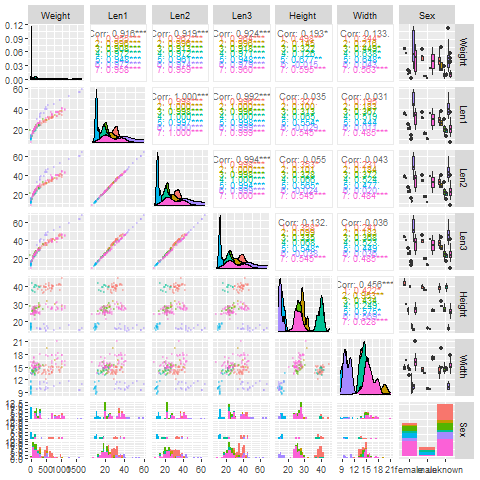

In [70]:
%%R
p <- fish %>%
  ggpairs(
    columns = 2:8,
    mapping = aes(color = Species),
    upper = list(continuous = wrap("cor", size = 3)),
    lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5))
  ) +
  theme(legend.position = "bottom") +
  labs(color = "Species Type")

# Save the plot with the desired dimensions (e.g., 12 inches by 8 inches)
ggsave("ggpairs_enlarged.png", p, width = 12, height = 8, dpi = 300)
p
# Display the saved image in the notebook
#IRdisplay::display_png("ggpairs_enlarged.png")

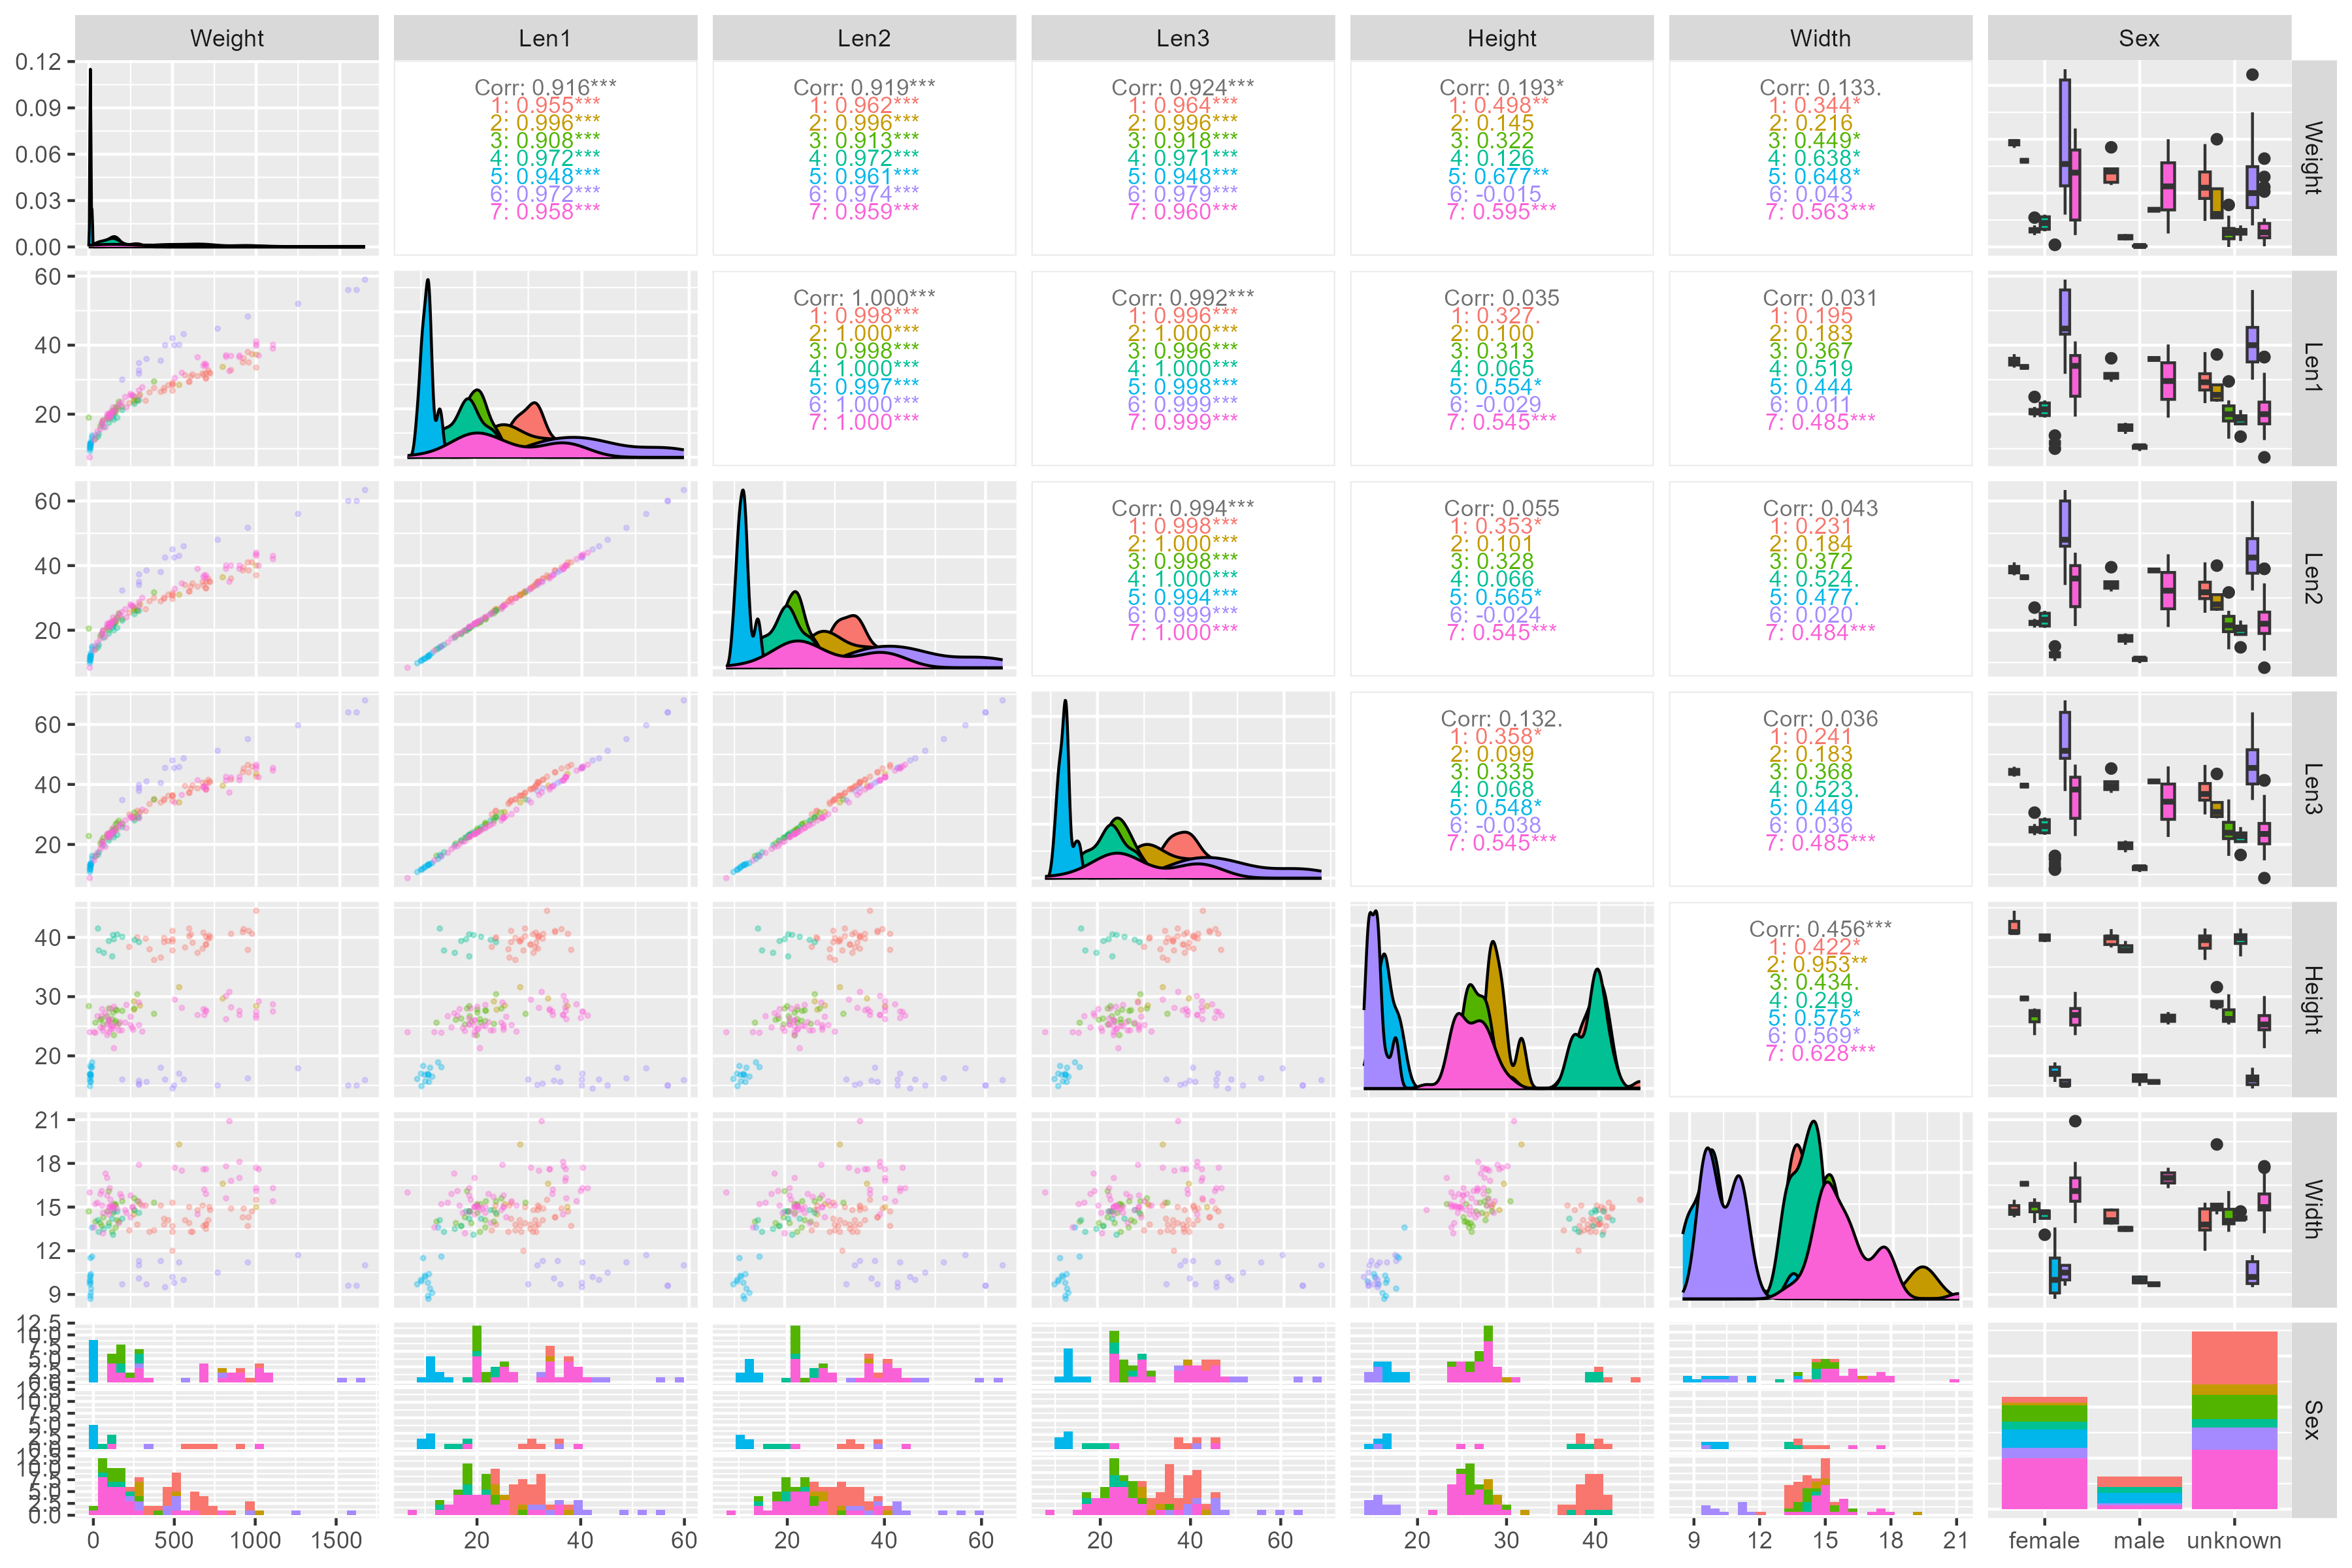

In [71]:
from IPython.display import Image, display
display(Image(filename="ggpairs_enlarged.png"))

# Regression


## What should you be able to do

* Recode Species, instead numeric use fish names.
* Which variables look promising, which variables can be omitted.
* Edit the dataset
* Plot Height vs. Weight, Leng3 vs. Weight, Width vs. Weight

### In R

In [72]:
%%R
summary(fish)

 Species     Weight            Len1            Len2            Len3      
 1:34    Min.   :   0.0   Min.   : 7.50   Min.   : 8.40   Min.   : 8.80  
 2: 6    1st Qu.: 120.0   1st Qu.:19.02   1st Qu.:21.00   1st Qu.:23.12  
 3:20    Median : 272.5   Median :25.10   Median :27.15   Median :29.35  
 4:11    Mean   : 398.7   Mean   :26.23   Mean   :28.39   Mean   :31.19  
 5:14    3rd Qu.: 650.0   3rd Qu.:32.70   3rd Qu.:35.75   3rd Qu.:39.67  
 6:17    Max.   :1650.0   Max.   :59.00   Max.   :63.40   Max.   :68.00  
 7:56                                                                    
     Height          Width            Sex    
 Min.   :14.50   Min.   : 8.70   female :55  
 1st Qu.:24.23   1st Qu.:13.40   male   :16  
 Median :27.00   Median :14.60   unknown:87  
 Mean   :28.26   Mean   :14.12               
 3rd Qu.:37.70   3rd Qu.:15.30               
 Max.   :44.50   Max.   :20.90               
                                             


In [73]:
%%R
Fish <- fish %>%
  filter(Species %in% c(1,3,7)) %>%
  mutate(Species = recode(Species,"1" = "Bream",
                                  "2" = "Whitewish",
                                  "3" = "Roach",
                                  "4" = "Blicca",
                                  "5" = "Smelt",
                                  "6" = "Pike",
                                  "7" = "Perch")) %>%
  mutate(Species = fct_drop(Species))%>%
  select(-Sex) %>%
  filter(Weight != 0)
head(Fish)
summary(Fish)

  Species       Weight            Len1           Len2            Len3      
 Bream:34   Min.   :   5.9   Min.   : 7.5   Min.   : 8.40   Min.   : 8.80  
 Roach:19   1st Qu.: 140.0   1st Qu.:20.5   1st Qu.:22.00   1st Qu.:24.00  
 Perch:56   Median : 300.0   Median :25.4   Median :27.50   Median :30.60  
            Mean   : 419.5   Mean   :26.3   Mean   :28.57   Mean   :31.54  
            3rd Qu.: 690.0   3rd Qu.:31.9   3rd Qu.:35.00   3rd Qu.:39.30  
            Max.   :1100.0   Max.   :41.1   Max.   :44.00   Max.   :46.60  
     Height          Width     
 Min.   :21.30   Min.   :12.0  
 1st Qu.:25.60   1st Qu.:14.1  
 Median :27.60   Median :15.0  
 Mean   :30.48   Mean   :15.1  
 3rd Qu.:38.10   3rd Qu.:15.7  
 Max.   :44.50   Max.   :20.9  


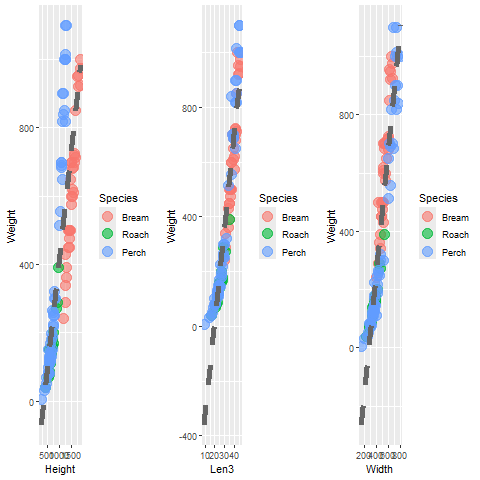

In [74]:
%%R -w 1200 -h 400
options(repr.plot.width = 15, repr.plot.height = 5, repr.plot.res = 90)

Fish <- Fish %>% mutate(Height = Height*Len3,
                        Width = Width*Len3)

Height_Weight <- ggplot(Fish,aes(x=Height,y=Weight,col=Species))+
                 geom_point(size=5,alpha=0.6)+
                 geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")

LengthV_Weight <- ggplot(Fish,aes(x=Len3,y=Weight,col=Species))+
                  geom_point(size=5,alpha=0.6)+
                  geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")

Width_Weight <- ggplot(Fish,aes(x=Width,y=Weight,col=Species))+
                 geom_point(size=5,alpha=0.6)+
                 geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")

#Height_Weight
#LengthV_Weight
#Width_Weight

grid.arrange(Height_Weight, LengthV_Weight, Width_Weight, ncol = 3)

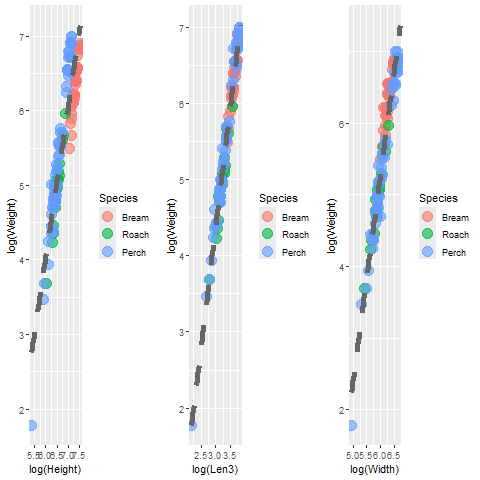

In [75]:
%%R -w 1600 -h 800

Width_Weight_log <- ggplot(Fish,aes(x=log(Width),y=log(Weight),col=Species))+
                 geom_point(size=5,alpha=0.6)+
                 geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")

LengthV_Weight_log <- ggplot(Fish,aes(x=log(Len3),y=log(Weight),col=Species))+
                  geom_point(size=5,alpha=0.6)+
                  geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")

Height_Weight_log  <- ggplot(Fish,aes(x=log(Height),y=log(Weight),col=Species))+
                 geom_point(size=5,alpha=0.6)+
                 geom_smooth(col="grey40",method = "lm",se=F,lty="dashed",lwd=2,formula="y~x")


grid.arrange(Height_Weight_log, LengthV_Weight_log, Width_Weight_log, ncol = 3)


In [76]:
%%R
# Model with all variables and interaction till 2nd order ...
m0  <- lm(Weight ~ (.)^2, data = Fish)
summary(m0)
# Ufff


Call:
lm(formula = Weight ~ (.)^2, data = Fish)

Residuals:
    Min      1Q  Median      3Q     Max 
-95.562 -14.925  -0.473  15.115 110.903 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)  
(Intercept)          8.563e+02  8.013e+02   1.069   0.2884  
SpeciesRoach        -5.280e+02  7.649e+02  -0.690   0.4920  
SpeciesPerch        -7.280e+02  7.971e+02  -0.913   0.3638  
Len1                 4.511e+02  2.174e+02   2.075   0.0411 *
Len2                -3.404e+02  3.085e+02  -1.103   0.2731  
Len3                -9.995e+01  2.395e+02  -0.417   0.6775  
Height              -4.422e-01  1.443e+00  -0.306   0.7600  
Width               -1.233e-01  2.516e+00  -0.049   0.9610  
SpeciesRoach:Len1   -3.421e+02  1.752e+02  -1.952   0.0544 .
SpeciesPerch:Len1   -4.220e+02  1.898e+02  -2.224   0.0290 *
SpeciesRoach:Len2    2.812e+02  2.846e+02   0.988   0.3259  
SpeciesPerch:Len2    3.410e+02  3.183e+02   1.071   0.2873  
SpeciesRoach:Len3    3.039e+01  2.194e+02   0.139

### In python:

In [77]:
# Display summary of the DataFrame in a table format
fish_summary = fish.describe(include='all').T
fish_summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Species,158.0,7.0,7.0,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,158.0,NaN,NaN,NaN,398.69557,359.086204,0.0,120.0,272.5,650.0,1650.0
Len1,158.0,NaN,NaN,NaN,26.226582,10.024844,7.5,19.025,25.1,32.7,59.0
Len2,158.0,NaN,NaN,NaN,28.393038,10.746572,8.4,21.0,27.15,35.75,63.4
Len3,158.0,NaN,NaN,NaN,31.188608,11.63701,8.8,23.125,29.35,39.675,68.0
Height,158.0,NaN,NaN,NaN,28.256329,8.296377,14.5,24.225,27.0,37.7,44.5
Width,158.0,NaN,NaN,NaN,14.11962,2.281229,8.7,13.4,14.6,15.3,20.9
Sex,158,3,unknown,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
Fish = fish[fish['Species'].isin([1, 3, 7]) & (fish['Weight'] != 0)].copy()

Fish['Height'] = Fish['Height'] * Fish['Len3']
Fish['Width'] = Fish['Width'] * Fish['Len3']

# Replace Species numbers with names using a map
# Recode Species values
species_map = {
    1: "Bream",
    2: "Whitewish",
    3: "Roach",
    4: "Blicca",
    5: "Smelt",
    6: "Pike",
    7: "Perch"
}
Fish['Species'] = Fish['Species'].map(species_map)

# Ensure the Species column is of categorical type
Fish['Species'] = Fish['Species'].astype('category')

# Drop the 'Sex' column
Fish = Fish.drop(columns=['Sex'])



In [79]:
# Display the first few rows of the DataFrame
print(Fish.head())

# Summary statistics for the DataFrame
fish_summary = Fish.describe(include='all').T
fish_summary


  Species  Weight  Len1  Len2  Len3   Height   Width
0   Bream   242.0  23.2  25.4  30.0  1152.00  402.00
1   Bream   290.0  24.0  26.3  31.2  1248.00  430.56
2   Bream   340.0  23.9  26.5  31.1  1237.78  469.61
3   Bream   363.0  26.3  29.0  33.5  1273.00  445.55
4   Bream   430.0  26.5  29.0  34.0  1244.40  513.40


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Species,109,3,Perch,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,109.0,NaN,NaN,NaN,419.544954,318.951254,5.9,140.0,300.0,690.0,1100.0
Len1,109.0,NaN,NaN,NaN,26.29633,7.362039,7.5,20.5,25.4,31.9,41.1
Len2,109.0,NaN,NaN,NaN,28.566972,7.88368,8.4,22.0,27.5,35.0,44.0
Len3,109.0,NaN,NaN,NaN,31.538532,8.864828,8.8,24.0,30.6,39.3,46.6
Height,109.0,NaN,NaN,NaN,995.582477,430.753751,211.2,616.77,887.68,1360.24,1895.7
Width,109.0,NaN,NaN,NaN,477.485872,148.376081,140.8,362.4,456.62,601.8,814.2


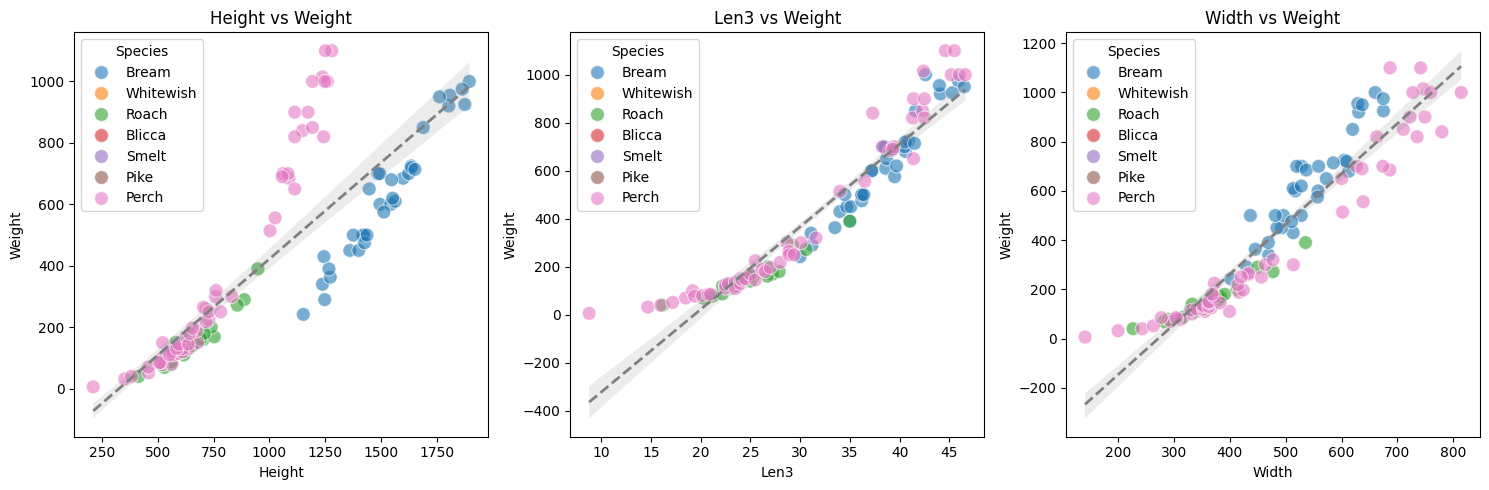

In [80]:
# Set a larger figure size: width 15, height 5 inches.
plt.figure(figsize=(15, 5))

# Plot 1: Height vs Weight
plt.subplot(1, 3, 1)
sns.scatterplot(data=Fish, x='Height', y='Weight', hue='Species', s=100, alpha=0.6)
sns.regplot(data=Fish, x='Height', y='Weight', scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("Height vs Weight")

# Plot 2: Len3 vs Weight
plt.subplot(1, 3, 2)
sns.scatterplot(data=Fish, x='Len3', y='Weight', hue='Species', s=100, alpha=0.6)
sns.regplot(data=Fish, x='Len3', y='Weight', scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("Len3 vs Weight")

# Plot 3: Width vs Weight
plt.subplot(1, 3, 3)
sns.scatterplot(data=Fish, x='Width', y='Weight', hue='Species', s=100, alpha=0.6)
sns.regplot(data=Fish, x='Width', y='Weight', scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("Width vs Weight")

# Adjust layout and show
plt.tight_layout()
plt.show()

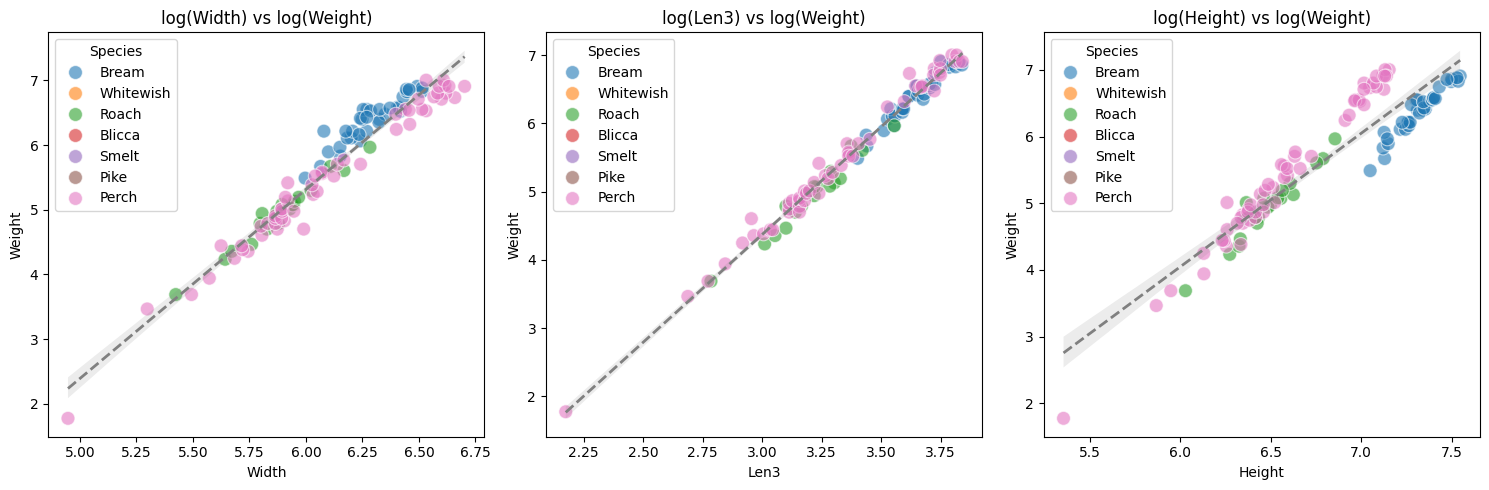

In [81]:
plt.figure(figsize=(15, 5))

# Plot 1: log(Width) vs log(Weight)
plt.subplot(1, 3, 1)
sns.scatterplot(x=np.log(Fish['Width']), y=np.log(Fish['Weight']),
                hue=Fish['Species'], s=100, alpha=0.6)
sns.regplot(x=np.log(Fish['Width']), y=np.log(Fish['Weight']),
            scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("log(Width) vs log(Weight)")

# Plot 2: log(Len3) vs log(Weight)
plt.subplot(1, 3, 2)
sns.scatterplot(x=np.log(Fish['Len3']), y=np.log(Fish['Weight']),
                hue=Fish['Species'], s=100, alpha=0.6)
sns.regplot(x=np.log(Fish['Len3']), y=np.log(Fish['Weight']),
            scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("log(Len3) vs log(Weight)")

# Plot 3: log(Height) vs log(Weight)
plt.subplot(1, 3, 3)
sns.scatterplot(x=np.log(Fish['Height']), y=np.log(Fish['Weight']),
                hue=Fish['Species'], s=100, alpha=0.6)
sns.regplot(x=np.log(Fish['Height']), y=np.log(Fish['Weight']),
            scatter=False, color='grey',
            line_kws={'linestyle': '--', 'linewidth': 2})
plt.title("log(Height) vs log(Weight)")

plt.tight_layout()
plt.show()


In [82]:
import statsmodels.formula.api as smf

# Ensure 'Species' is treated as categorical.
Fish['Species'] = Fish['Species'].astype('category')

# List predictors (all columns except 'Weight')
predictors = list(Fish.columns)
predictors.remove('Weight')

# Build the formula string, e.g. "Weight ~ (Len1 + Len2 + Len3 + Height + Width + Species)**2"
formula = "Weight ~ (" + " + ".join(predictors) + ")**2"
model = smf.ols(formula, data=Fish).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     240.6
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.90e-66
Time:                        09:29:38   Log-Likelihood:                -542.92
No. Observations:                 109   AIC:                             1142.
Df Residuals:                      81   BIC:                             1217.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### Questions:
* How can you interpret previous result?
* Comment and discussion: how to select model.


In [83]:
%%R
m0_BIC  <- stepAIC(m0, k=log(dim(Fish)[1]))

m0_AIC  <- stepAIC(m0)
summary(m0_BIC)
summary(m0_AIC)

Start:  AIC=907.86
Weight ~ (Species + Len1 + Len2 + Len3 + Height + Width)^2

                 Df Sum of Sq    RSS    AIC
- Species:Len3    2      68.3 135368 898.53
- Species:Height  2     118.2 135418 898.58
- Species:Width   2     406.7 135706 898.81
- Species:Len2    2    1942.9 137242 900.03
- Len3:Height     1      24.4 135324 903.19
- Len1:Len2       1      49.7 135349 903.21
- Len3:Width      1      73.9 135373 903.23
- Len1:Len3       1     110.2 135410 903.26
- Len2:Len3       1     139.4 135439 903.28
- Len2:Height     1    1103.1 136403 904.06
- Height:Width    1    1273.6 136573 904.19
- Len2:Width      1    1903.5 137203 904.69
- Species:Len1    2    8382.3 143682 905.03
- Len1:Width      1    3275.6 138575 905.78
- Len1:Height     1    4640.7 139940 906.85
<none>                        135300 907.86

Step:  AIC=898.53
Weight ~ Species + Len1 + Len2 + Len3 + Height + Width + Species:Len1 + 
    Species:Len2 + Species:Height + Species:Width + Len1:Len2 + 
    Len1:Len3 + 

In [84]:
%%R
install.packages("leaps")
library(leaps)

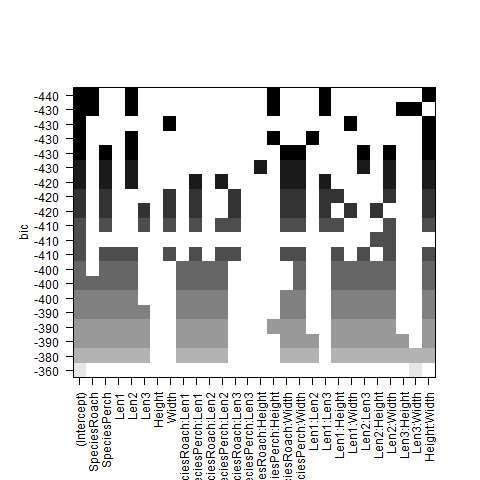

In [85]:
%%R
best_subset <- regsubsets(Weight ~ (.)^2, Fish, nvmax = 20,really.big=T)
results <- summary(best_subset)
plot(best_subset)


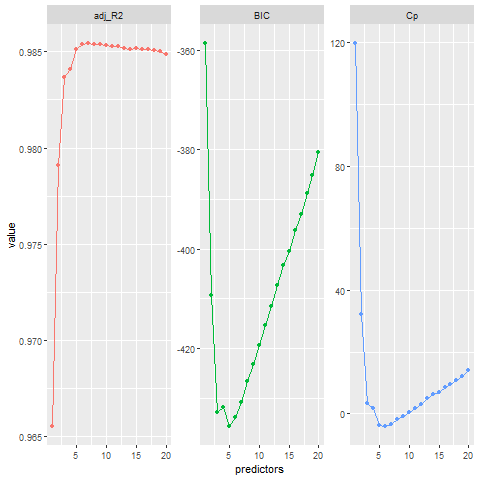

In [86]:
%%R
# source: https://afit-r.github.io/model_selection
tibble(predictors = 1:20,
       adj_R2 = results$adjr2,
       Cp = results$cp,
       BIC = results$bic) %>%
  gather(statistic, value, -predictors) %>%
  ggplot(aes(predictors, value, color = statistic)) +
  geom_line(show.legend = F) +
  geom_point(show.legend = F) +
  facet_wrap(~ statistic, scales = "free")

#### AIC and BIC

**AIC:**
$
AIC = -2 \log L + 2p \approx n \log( \frac{SS_{\text{residuals}}}{n})  + 2p \approx  n \log(\hat{\sigma}^2) + 2p
$

**BIC:**
$
BIC = -2 \log L + p \log n \approx n \log( \frac{SS_{\text{residuals}}}{n}) + p \log n \approx  n \log(\hat{\sigma}^2) + p \log n
$

**Mallows':**
$
C_{p}=\frac{SS_{\text{residuals p}}}{\hat{\sigma}^2} - n + 2p
$



# Your turn 02 (run analysis in Python)

* Is there problem with multicolinearity? If so, how can we cope with it.
* Try to find such a good model (based on adjuste R^2) with a maximum of 7 covariates.

Hint: try to use expert knowledge.

I will continue in R.

In [87]:
%%R
m1 <- lm(Weight ~ (.), data = Fish)
summary(m1)


Call:
lm(formula = Weight ~ (.), data = Fish)

Residuals:
    Min      1Q  Median      3Q     Max 
-139.69  -41.71  -13.77   35.64  282.25 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -789.1469   117.0209  -6.744 9.79e-10 ***
SpeciesRoach  222.2885    81.6941   2.721  0.00767 ** 
SpeciesPerch  254.2909   113.2402   2.246  0.02691 *  
Len1            4.0467    32.5372   0.124  0.90127    
Len2           22.4708    43.6348   0.515  0.60770    
Len3          -21.3108    29.7990  -0.715  0.47617    
Height          0.6927     0.1288   5.377 4.89e-07 ***
Width           0.5727     0.2189   2.616  0.01025 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 72 on 101 degrees of freedom
Multiple R-squared:  0.9523,	Adjusted R-squared:  0.949 
F-statistic: 288.4 on 7 and 101 DF,  p-value: < 2.2e-16



In [88]:
%%R
# VIF
print(1/(1-(summary(lm(Len1 ~.,data = Fish %>% select(-Weight)))$r.squared)))
print(1/(1-(summary(lm(Len2 ~.,data = Fish %>% select(-Weight)))$r.squared)))
print(1/(1-(summary(lm(Len3 ~.,data = Fish %>% select(-Weight)))$r.squared)))
print(1/(1-(summary(lm(Height ~.,data = Fish %>% select(-Weight)))$r.squared)))
print(1/(1-(summary(lm(Width  ~.,data = Fish %>% select(-Weight)))$r.squared)))

[1] 1195.547
[1] 2465.661
[1] 1453.963
[1] 64.14466
[1] 21.9837


In [89]:
%%R
kappa(scale(data.matrix(Fish)))
kappa(scale(data.matrix(Fish %>% select(-Len1,-Len2))))

[1] 11.7315


In [90]:
%%R
m1 <- lm(Weight ~ Species+Len2:Len3:Height+Len2:Len3:Width, data = Fish)
summary(m1)


Call:
lm(formula = Weight ~ Species + Len2:Len3:Height + Len2:Len3:Width, 
    data = Fish)

Residuals:
    Min      1Q  Median      3Q     Max 
-153.42  -14.75   -3.83   11.67  150.46 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       3.685e+01  2.214e+01   1.664 0.099088 .  
SpeciesRoach     -3.993e+01  2.356e+01  -1.695 0.093012 .  
SpeciesPerch     -3.004e+01  2.336e+01  -1.286 0.201328    
Len2:Len3:Height  9.174e-05  2.654e-05   3.457 0.000793 ***
Len2:Len3:Width   5.618e-04  4.924e-05  11.408  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 44.84 on 104 degrees of freedom
Multiple R-squared:  0.981,	Adjusted R-squared:  0.9802 
F-statistic:  1340 on 4 and 104 DF,  p-value: < 2.2e-16



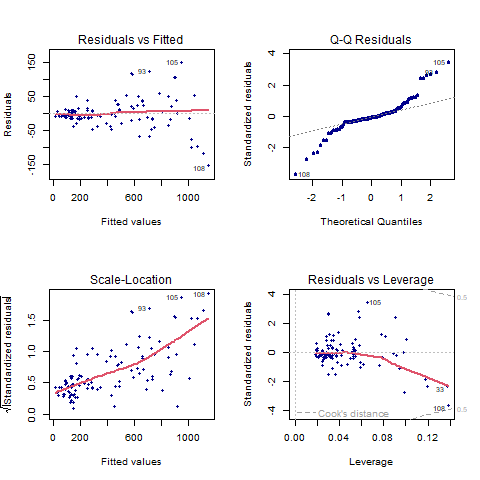

In [91]:
%%R
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 90)

par(mfrow = c(2, 2))
plot(m1, pch = 20, col = "blue4", lwd = 2)


In [92]:
%%R
log_m1 <- lm(log(Weight) ~ Species+Len2:Len3:Height+Len2:Len3:Width, data = Fish)
summary(log_m1)


Call:
lm(formula = log(Weight) ~ Species + Len2:Len3:Height + Len2:Len3:Width, 
    data = Fish)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.64423 -0.09038  0.07184  0.20479  0.58785 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       5.275e+00  1.989e-01  26.521  < 2e-16 ***
SpeciesRoach     -7.610e-01  2.116e-01  -3.596 0.000496 ***
SpeciesPerch     -8.776e-01  2.099e-01  -4.182 6.05e-05 ***
Len2:Len3:Height -4.205e-07  2.384e-07  -1.764 0.080719 .  
Len2:Len3:Width   2.714e-06  4.424e-07   6.136 1.56e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4028 on 104 degrees of freedom
Multiple R-squared:  0.8383,	Adjusted R-squared:  0.8321 
F-statistic: 134.8 on 4 and 104 DF,  p-value: < 2.2e-16



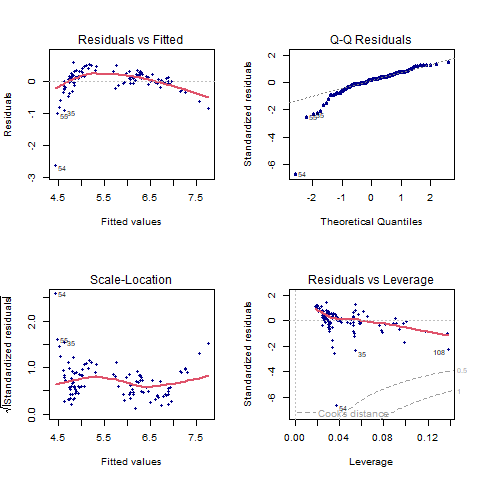

In [93]:
%%R
par(mfrow = c(2, 2))
plot(log_m1, pch = 20, col = "blue4", lwd = 2)


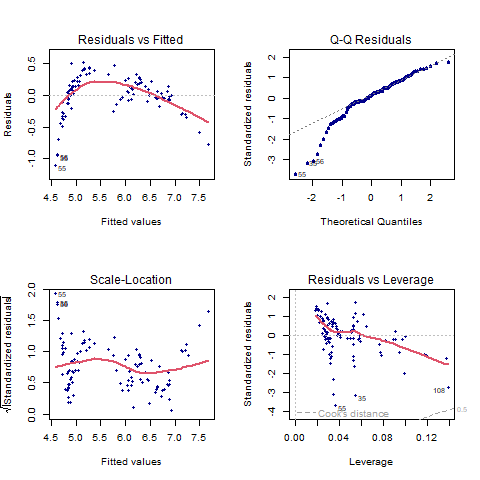

In [94]:
%%R
log_m1 <- lm(log(Weight) ~ Species+Len2:Len3:Height+Len2:Len3:Width, data = Fish[-54,])
par(mfrow = c(2, 2))
plot(log_m1, pch = 20, col = "blue4", lwd = 2)


[1] 0.88


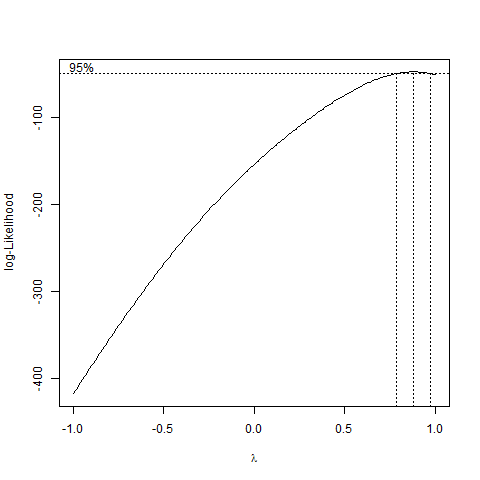

In [95]:
%%R
# Box-Cox transformation
BC_m0  <- lm(Weight ~ Species+I(Len3^2) +Len3:Height:Width, data = Fish)
summary(BC_m0)
bc     <- boxcox(m1, lambda = seq(-1,1 , 1/100))
lambda <- bc$x[which.max(bc$y)]
lambda

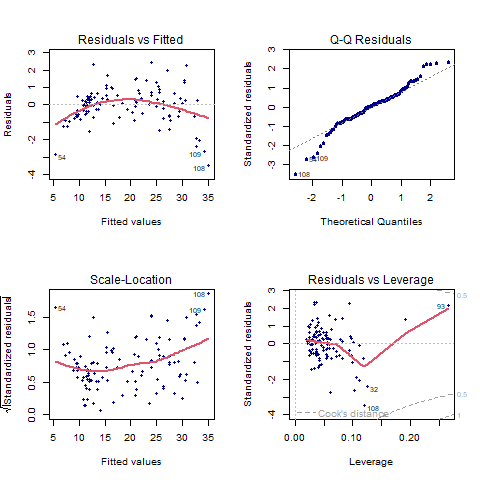

In [96]:
%%R
BC_m1 <- lm(Weight^(1/2) ~ Species+I(Len3^2) + Len3:Height+Len3:Width, data = Fish)
summary(BC_m1)

#Fish$Weight_lambda = (Fish$Weight^lambda-1)/lambda
#BC_m1 <- lm(Weight_lambda  ~ Species+I(Len3^2) + Len3:Height+Len3:Width, data = Fish)

summary(BC_m1)
par(mfrow = c(2, 2))
plot(BC_m1, pch = 20, col = "blue4", lwd = 2)


In [97]:
%%R
#install.packages("pbkrtest")
#install.packages("lme4")
#install.packages("RcppEigen")
#install.packages("car")
#library(car)

NULL


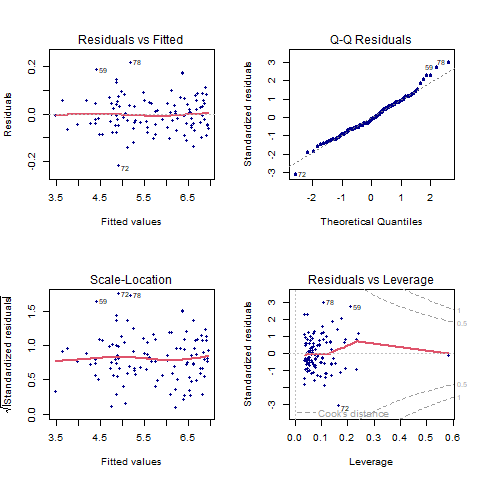

In [98]:
%%R
m_f <- lm(log(Weight) ~ Species+log(Len3)*log(Height)*log(Width), data = Fish[-54,])
summary(m_f)

#Fish$Weight_lambda = (Fish$Weight^lambda-1)/lambda
#BC_m1 <- lm(Weight_lambda  ~ Species+I(Len3^2) + Len3:Height+Len3:Width, data = Fish)

summary(m_f)
par(mfrow = c(2, 2))
plot(m_f, pch = 20, col = "blue4", lwd = 2)


Is linear regression clear?

# Let's start with GLM

##  Necessary theory recap from Lectures 01-03

Let's consider (m1):
  1. We have an *i.i.d.* sample $(y_i,\ldots,y_n)$ from random variables $Y_1,\ldots,Y_n$ with PDF (Probability Density Function) $f(y;\theta;\phi)$ in the exponential (one-parameter) family of probability distributions
  $$f(y;\theta;\phi) = exp\left(\frac{y \theta - b(\theta)}{a(\phi)} + c(y,\phi)\right),$$
  subject to usual regularity conditions  (one dimensional case, i.e. $y_i,\theta_i \in R, a(\phi) >0, \phi >0)$.
  2. **A regression matrix** $X$ and vector of unknown parameters $\beta$, which define the **linear predictor**
    $$ η = X \beta $$
  3. **A link function** $g(⋅)$
  $$\eta_i = g(\mu_i) = x_i^T \beta, \ \text{where} \ \mu_i = E[Y_i] \ \ i = 1,\ldots,n$$

The **dispersion** $a(\phi)$ is typically known. If not, we take it as **nuisance parameter**.

Link function satisfying $g(\mu_i) = \theta_i$ is called **canonical**.

For $b(\theta) \in C^2$ we showed:
$$E[Y] = b'(\theta) $$
$$V[Y] = a(\phi) b''(\theta) $$
and defined variance function $v(\mu) = \frac{\partial \mu}{\partial \theta}$, so that  $$V[Y] = a(\phi) v(\mu)$$

Relations:

$$
\beta \xrightarrow[]{\eta_i = x_i^T\beta} \eta
\xrightarrow[]{\mu_i = g^{-1}(\eta_i)}  \mu
\xrightarrow[]{\theta_i = (b')^{-1}(\mu_i)}  \theta
$$

Inverse relations
$$
\eta_i
\xleftarrow[]{}  \mu
\xleftarrow[]{}  \theta
$$


**Lemma**:
Let Y have an exponential type distribution with density given in m1, where $b(\theta)$ is 2 times continuously differentiable, then there exists a everywhere finite moment generating function $M_Y(t) = E[e^{ty}]$ that is 2 times differentiable at 0 and it holds:
* $E[Y] = b'(\theta)$
* $V[Y] = a(\phi) b''(\theta)$

## HW 01

Compute $E[Y]$, $V[Y]$, and $v(Y)$ by the help of moment generating function theory for the following so-called “big five” Exponential Family  distributions (Normal, Poisson, Gamma, Inverse Gaussian, Binomial)

* Normal: $N(\mu,\sigma^2)$
* Poisson: $Poi(\lambda)$
* Bernoulli: $Ber(p)$

  $f(y,p) = p^y(1-p)^{1-y}$
* Gamma: $\Gamma[a,p]$

 $ {\displaystyle f(y,a,p)={\frac {a ^{p }}{\Gamma (p)}}y^{p -1}e^{-a y}}$
* Inverse: Gaussian $IG[\mu, \lambda]$

  ${\displaystyle f(y;\mu ,\lambda )={\sqrt {\frac {\lambda }{2\pi y^{3}}}}\exp {\biggl (}-{\frac {\lambda (y-\mu )^{2}}{2\mu ^{2}y}}{\biggr )}}$


Questions:
* Which distributions can fulfill homoscedasticity and why?
* For which distribution the variance increases with the square of the mean value?
* Does exists a distribution, where $V[Y] = k \cdot \mu$ ?


## Solution

####  Normal:

$N(\mu,\sigma^2)$

$f(y, \mu, \sigma^2) = \frac{1}{\sqrt {{(2\pi )} \sigma^2}}  {\mathrm {e}}^-{\frac{{\left(y- \mu \right)}^{T}{\left( y-\mu \right)}}{\sigma^2}} = ...
$
<!---

${\mathrm {e}}^{\frac{y \mu - \frac{\mu^2}{2}}{\sigma^2} - \left(  \frac{y^2}{2\sigma^2} + \frac{1}{2} ln(2 \pi \sigma^2) \right)}$

 $y \theta - b(\theta) = \frac{y \mu - \frac{\mu^2}{2}}{\sigma^2} ⇒ b(\theta) = \frac{\theta^2}{2}$

* Natural parameter: $\theta = \mu  \Rightarrow b(\theta) = \frac{\mu^2}{2}$
* Dispersion function: $\phi = \sigma^2 ⇒ a(\phi) = \sigma^2$
*  $E[Y] = b'(\theta) = \theta = \mu$
* $V[Y] = \sigma^2 b''(\theta)= \sigma^2 $

Linear variance function: $v(\mu) = b''(\theta) =  1$
-->

#### Bernoulli: $Ber(p)$

  $f(y,p) = p^y(1-p)^{1-y} = ...$

<!---  $exp(y \textrm{ln}(p) + (1-y)\textrm{ln}(1-p)) = exp(y \textrm{ln}(\frac{p}{1-p}) + ln(1-p))$

* $\phi = 1$ and $b(\theta) = ln(1+e^{\theta})$ and $\theta = \textrm{ln}(\frac{p}{1-p}) ⇒ p = \frac{e^{\theta}}{1+e^{\theta}}$
* $ E[Y] =  b'(\theta) = \frac{e^{\theta}}{1+e^{\theta}} = p$
* $ V[Y] = b''(\theta) = \frac{e^{\theta}}{1+e^{\theta}} - e^{\theta} \frac{e^{\theta}}{(1+e^{\theta})^2} = p - p^2 = p(1-p)$
* Variance function: $v(\mu) = \mu(1-\mu)$
--->

####  Poisson: $Poi(\lambda)$

$f(y,\lambda) = \frac{\lambda^y e^{-\lambda}}{y!} = ... $

<!--

$ exp(y ln(\lambda)  -\lambda -ln(y!)) $

* $\theta = ln(\lambda) \Rightarrow b(\theta) = e^{\theta}  \ \text{and} \  \phi = 1$
*  $E[Y] = b'(\theta) = e^{\theta} = \lambda$
* $V[Y] = b''(\theta)=e^{\theta} = \lambda$

Linear variance function: $v(\mu) = \mu$

-->


###  Gamma Distribution $\Gamma(a,p)$

- Shape $p>0$,  
- Rate $a>0$
- Support $x>0$  

$$
f(y;\,a,p)
\;=\;
\frac{a^p}{\Gamma(p)}\,y^{\,p-1}\,e^{-\,a\,y},
\quad y>0.
$$


#### Inverse Gauss

$$
f(y;\,\mu,\lambda)
\;=\;
\sqrt{\frac{\lambda}{2\pi\,y^3}}
\,\exp\!\Bigl[-\frac{\lambda\,(y-\mu)^2}{2\,\mu^2\,y}\Bigr],
\quad y>0.
$$


## Solutions

See [01ZLMA_ex01_LLM_solutions.ipynb](01ZLMA_ex01_LLM_solutions.ipynb) for detailed derivations of the variance functions for all six distributions.

In [99]:
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(42)
n_samples = 10000  # samples per simulation
n_sims = 100       # number of simulations

In [100]:
# --- Normal: Monte Carlo verification ---
mu_true, sigma2_true = 5.0, 4.0
means, variances = [], []
for _ in range(n_sims):
    y = np.random.normal(loc=mu_true, scale=np.sqrt(sigma2_true), size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

print("=== Normal N(mu={}, sigma^2={}) ===".format(mu_true, sigma2_true))
print(f"  Theoretical E[Y]   = {mu_true}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {sigma2_true}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu) = 1  =>  Var[Y] / sigma^2 = {np.mean(variances)/sigma2_true:.4f}  (should be ~1)")

=== Normal N(mu=5.0, sigma^2=4.0) ===
  Theoretical E[Y]   = 5.0
  Simulated   E[Y]   = 4.9968  (std over sims: 0.0192)
  Theoretical Var[Y] = 4.0
  Simulated   Var[Y] = 4.0015  (std over sims: 0.0537)
  v(mu) = 1  =>  Var[Y] / sigma^2 = 1.0004  (should be ~1)


In [101]:
# --- Poisson: Monte Carlo verification ---
lam_true = 7.0
means, variances = [], []
for _ in range(n_sims):
    y = np.random.poisson(lam=lam_true, size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

print("=== Poisson(lambda={}) ===".format(lam_true))
print(f"  Theoretical E[Y]   = {lam_true}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {lam_true}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu)=mu  =>  Var[Y] / E[Y] = {np.mean(variances)/np.mean(means):.4f}  (should be ~1)")

=== Poisson(lambda=7.0) ===
  Theoretical E[Y]   = 7.0
  Simulated   E[Y]   = 6.9975  (std over sims: 0.0262)
  Theoretical Var[Y] = 7.0
  Simulated   Var[Y] = 6.9892  (std over sims: 0.1035)
  v(mu)=mu  =>  Var[Y] / E[Y] = 0.9988  (should be ~1)


In [102]:
# --- Bernoulli: Monte Carlo verification ---
p_true = 0.3
means, variances = [], []
for _ in range(n_sims):
    y = np.random.binomial(n=1, p=p_true, size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

print("=== Bernoulli(p={}) ===".format(p_true))
print(f"  Theoretical E[Y]   = {p_true}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {p_true*(1-p_true):.4f}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu)=mu(1-mu) = {p_true*(1-p_true):.4f}")

=== Bernoulli(p=0.3) ===
  Theoretical E[Y]   = 0.3
  Simulated   E[Y]   = 0.2995  (std over sims: 0.0042)
  Theoretical Var[Y] = 0.2100
  Simulated   Var[Y] = 0.2098  (std over sims: 0.0017)
  v(mu)=mu(1-mu) = 0.2100


In [103]:
# --- Binomial: Monte Carlo verification ---
n_binom, p_true = 20, 0.4
means, variances = [], []
for _ in range(n_sims):
    y = np.random.binomial(n=n_binom, p=p_true, size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

mu_true = n_binom * p_true
var_true = n_binom * p_true * (1 - p_true)

print("=== Binomial(n={}, p={}) ===".format(n_binom, p_true))
print(f"  Theoretical E[Y]   = {mu_true}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {var_true:.4f}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu)=mu(1-mu/n) = {mu_true*(1 - mu_true/n_binom):.4f}")

=== Binomial(n=20, p=0.4) ===
  Theoretical E[Y]   = 8.0
  Simulated   E[Y]   = 8.0010  (std over sims: 0.0231)
  Theoretical Var[Y] = 4.8000
  Simulated   Var[Y] = 4.7900  (std over sims: 0.0615)
  v(mu)=mu(1-mu/n) = 4.8000


In [104]:
# --- Gamma: Monte Carlo verification ---
# Gamma(shape=p, rate=a): E[Y]=p/a, Var[Y]=p/a^2
p_shape, a_rate = 3.0, 2.0
mu_true = p_shape / a_rate
var_true = p_shape / a_rate**2
means, variances = [], []
for _ in range(n_sims):
    # numpy uses shape and scale=1/rate
    y = np.random.gamma(shape=p_shape, scale=1.0/a_rate, size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

print("=== Gamma(shape={}, rate={}) ===".format(p_shape, a_rate))
print(f"  Theoretical E[Y]   = {mu_true:.4f}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {var_true:.4f}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu)=mu^2 = {mu_true**2:.4f},  Var/a(phi) = {np.mean(variances) * p_shape:.4f}  (should be ~{mu_true**2:.4f})")

=== Gamma(shape=3.0, rate=2.0) ===
  Theoretical E[Y]   = 1.5000
  Simulated   E[Y]   = 1.5007  (std over sims: 0.0078)
  Theoretical Var[Y] = 0.7500
  Simulated   Var[Y] = 0.7498  (std over sims: 0.0132)
  v(mu)=mu^2 = 2.2500,  Var/a(phi) = 2.2495  (should be ~2.2500)


In [105]:
# --- Inverse Gaussian: Monte Carlo verification ---
mu_true, lam_true = 3.0, 5.0
var_true = mu_true**3 / lam_true
means, variances = [], []
for _ in range(n_sims):
    y = np.random.wald(mean=mu_true, scale=lam_true, size=n_samples)
    means.append(np.mean(y))
    variances.append(np.var(y, ddof=1))

print("=== Inverse Gaussian(mu={}, lambda={}) ===".format(mu_true, lam_true))
print(f"  Theoretical E[Y]   = {mu_true:.4f}")
print(f"  Simulated   E[Y]   = {np.mean(means):.4f}  (std over sims: {np.std(means):.4f})")
print(f"  Theoretical Var[Y] = {var_true:.4f}")
print(f"  Simulated   Var[Y] = {np.mean(variances):.4f}  (std over sims: {np.std(variances):.4f})")
print(f"  v(mu)=mu^3 = {mu_true**3:.4f},  Var/a(phi) = Var*lambda = {np.mean(variances)*lam_true:.4f}  (should be ~{mu_true**3:.4f})")

=== Inverse Gaussian(mu=3.0, lambda=5.0) ===
  Theoretical E[Y]   = 3.0000
  Simulated   E[Y]   = 2.9977  (std over sims: 0.0224)
  Theoretical Var[Y] = 5.4000
  Simulated   Var[Y] = 5.4116  (std over sims: 0.1676)
  v(mu)=mu^3 = 27.0000,  Var/a(phi) = Var*lambda = 27.0581  (should be ~27.0000)


# Extended Theory: Variance Functions and the Exponential Family
The variance function $v(\mu)$ is arguably **one of the most important modeling choices** in the GLM framework — often more consequential than the choice of link function. This section explains why.

## 1. The Uniqueness Theorem (Morris, 1982)

A fundamental result in the theory of natural exponential families (NEF):

**Theorem (Morris, 1982):** A natural exponential family is **uniquely characterized** by its variance function $V(\mu)$ and its mean domain $M$. If two NEFs share the same $V(\mu)$ on the same $M$, they are the same family of distributions.

**Reconstruction procedure:** Given $V(\mu)$, we can recover the natural parameter via$$\theta(\mu) = \int \frac{d\mu}{V(\mu)}$$and then the cumulant function $\kappa(\theta)$ by inverting $\mu(\theta)$ and integrating $\kappa'(\theta) = \mu$.

**Example — Poisson:** $V(\mu) = \mu$, so $\theta = \int \frac{d\mu}{\mu} = \ln \mu$, giving $\mu = e^\theta$ and $\kappa(\theta) = e^\theta$. This uniquely identifies the Poisson family.

**Jorgensen (1987)** extended this to **Exponential Dispersion Models** (EDMs), where $\mathrm{Var}[Y] = \phi \cdot V(\mu)$. The unit variance function $V(\mu)$ still uniquely characterizes the EDM family.

**Implication for GLMs:** Within NEF/EDM theory, the variance function $V(\mu)$ together with the mean domain characterizes the distributional family. This is not just a "modeling assumption" — it is the complete specification of the stochastic model (up to the dispersion parameter).

## 2. Morris Classification: Six NEFs with Quadratic Variance Functions

Morris (1982) completely classified all NEFs with quadratic $V(\mu) = v_0 + v_1\mu + v_2\mu^2$. There are exactly **six** such families:

| Distribution | $V(\mu)$ | Mean Domain $M$ | Canonical Link |
|:---|:---|:---|:---|
| Normal | $1$ (constant) | $(-\infty, \infty)$ | identity |
| Poisson | $\mu$ | $(0, \infty)$ | log |
| Gamma | $\mu^2$ | $(0, \infty)$ | reciprocal$^*$ |
| Binomial $(n)$ | $\mu(1 - \mu/n)$ | $(0, n)$ | logit |
| Negative Binomial $(k)$ | $\mu + \mu^2/k$ | $(0, \infty)$ | log |
| NEF-GHS (hyperbolic secant distribution) | $\mu^2 + 1$ | $(-\infty, \infty)$ | — |

$^*$ Strictly, the canonical link satisfies $g(\mu)=\theta$, which for Gamma gives $g(\mu)=-1/\mu$. The sign is absorbed by convention — see the LLM solutions notebook (Section 2) or Lecture notes Chapter 2.

Here $V(\mu)$ denotes the **unit variance function** $v(\mu)$ from the GLM decomposition $\mathrm{Var}[Y] = a(\phi)\,v(\mu)$.

These are sometimes called the **Morris families**. They are connected to the six classical orthogonal polynomial systems (Hermite, Charlier, Laguerre, Krawtchouk, Meixner, Meixner-Pollaczek).

## 4. Quasi-Likelihood: When $V(\mu)$ Is All You Need

**Wedderburn (1974)** showed that for estimating $\beta$ in a GLM, you do **not need to specify the full distribution** — only:
1. The mean: $E[Y_i] = \mu_i = g^{-1}(\mathbf{x}_i^T\beta)$
2. The variance function: $\mathrm{Var}(Y_i) = \phi \cdot V(\mu_i)$

The **quasi-log-likelihood** for observation $i$ is defined via:$$Q_i(y_i; \mu_i) = \int_{y_i}^{\mu_i} \frac{y_i - t}{\phi \cdot V(t)} \, dt$$

**Key properties of quasi-likelihood estimators** (Wedderburn, 1974; McCullagh, 1983):
- **Consistent**: $\hat{\beta} \xrightarrow{P} \beta_0$ as $n \to \infty$
- **Asymptotically normal**: $\sqrt{n}(\hat{\beta} - \beta_0) \xrightarrow{d} N(0, \ldots)$
- **Optimal**: Among all unbiased estimating equations depending on $y_i$ and $\mu_i$, the quasi-score equations have **minimum asymptotic variance** (Godambe-Durbin optimality)

**Practical consequence:** If you choose the correct $V(\mu)$, your parameter estimates will be efficient even without knowing the full likelihood. The variance function is more fundamental than the distributional form.

## 6. Why $V(\mu)$ Matters More Than the Link Function

The variance function is central to the GLM framework because:
1. **It determines the IRLS weights**: $w_i = 1 / [V(\mu_i)(g'(\mu_i))^2]$
2. **It determines inference**: standard errors, deviance, test statistics
3. **It uniquely identifies the distribution** (Morris/Jorgensen theorem)
4. **It suffices for consistent estimation** (Wedderburn quasi-likelihood)
5. **It is scientifically interpretable**: it encodes how variability scales with the response level

Misspecifying the link and misspecifying the variance function have different consequences. In many settings, variance misspecification primarily distorts standard errors and inference, while link misspecification affects the estimated mean structure. The practical impact depends on the degree of misspecification and the data at hand.

### References

- Morris, C.N. (1982). [Natural Exponential Families with Quadratic Variance Functions](https://doi.org/10.1214/aos/1176345690). *The Annals of Statistics*, 10(1), 65–80.
- Jørgensen, B. (1987). [Exponential Dispersion Models](https://doi.org/10.1111/j.2517-6161.1987.tb01685.x). *Journal of the Royal Statistical Society: Series B*, 49(2), 127–145.  
- Jørgensen, B. (1997). [*The Theory of Dispersion Models*](https://search.worldcat.org/title/The-theory-of-dispersion-models/oclc/37558238). Chapman & Hall.
- Wedderburn, R.W.M. (1974). [Quasi-likelihood functions, generalized linear models, and the Gauss–Newton method](https://doi.org/10.1093/biomet/61.3.439). *Biometrika*, 61(3), 439–447.
- McCullagh, P., & Nelder, J.A. (1989). [*Generalized Linear Models* (2nd ed.)](https://www.routledge.com/Generalized-Linear-Models-Second-Edition/McCullagh-%20Nelder/p/book/9780412317606). Chapman & Hall.
- Tweedie, M.C.K. (1984). "An Index which Distinguishes between Some Important Exponential Families." In [*Statistics: Applications and New Directions*](https://books.google.com/books/about/Statistics_Applications_and_New_Directio.html?id=S7jWMwAACAAJ) (Proc. Indian Statistical Institute Golden Jubilee Conference), 579–604.
- McCullagh, P. (1983). [Quasi-Likelihood Functions](https://doi.org/10.1214/aos/1176346056). *The Annals of Statistics*, 11(1), 59–67.

## 6. Why $V(\mu)$ Matters More Than the Link Function

The variance function is central to the GLM framework because:
1. **It determines the IRLS weights**: $w_i = 1 / [V(\mu_i)(g'(\mu_i))^2]$
2. **It determines inference**: standard errors, deviance, test statistics
3. **It uniquely identifies the distribution** (Morris/Jorgensen theorem)
4. **It suffices for consistent estimation** (Wedderburn quasi-likelihood)
5. **It is scientifically interpretable**: it encodes how variability scales with the response level

Misspecifying the link function typically leads to bias in $\hat{\mu}$ but consistent estimation of the mean-variance relationship. Misspecifying $V(\mu)$ leads to **incorrect standard errors** and **invalid inference**, even if the point estimates remain reasonable.



### References

- Morris, C.N. (1982). [Natural Exponential Families with Quadratic Variance Functions](https://doi.org/10.1214/aos/1176345690). *The Annals of Statistics*, 10(1), 65–80.
- Jørgensen, B. (1987). [Exponential Dispersion Models](https://doi.org/10.1111/j.2517-6161.1987.tb01685.x). *Journal of the Royal Statistical Society: Series B*, 49(2), 127–145.  
- Jørgensen, B. (1997). [*The Theory of Dispersion Models*](https://search.worldcat.org/title/The-theory-of-dispersion-models/oclc/37558238). Chapman & Hall.
- Wedderburn, R.W.M. (1974). [Quasi-likelihood functions, generalized linear models, and the Gauss–Newton method](https://doi.org/10.1093/biomet/61.3.439). *Biometrika*, 61(3), 439–447.
- McCullagh, P., & Nelder, J.A. (1989). [*Generalized Linear Models* (2nd ed.)](https://www.routledge.com/Generalized-Linear-Models-Second-Edition/McCullagh-%20Nelder/p/book/9780412317606). Chapman & Hall.
- Tweedie, M.C.K. (1984). "An Index which Distinguishes between Some Important Exponential Families." In [*Statistics: Applications and New Directions*](https://books.google.com/books/about/Statistics_Applications_and_New_Directio.html?id=S7jWMwAACAAJ) (Proc. Indian Statistical Institute Golden Jubilee Conference), 579–604.
- McCullagh, P. (1983). [Quasi-Likelihood Functions](https://doi.org/10.1214/aos/1176346056). *The Annals of Statistics*, 11(1), 59–67.
